In [2]:
from Stocketal2008 import run_model_test

import xarray as xr

import numpy as np

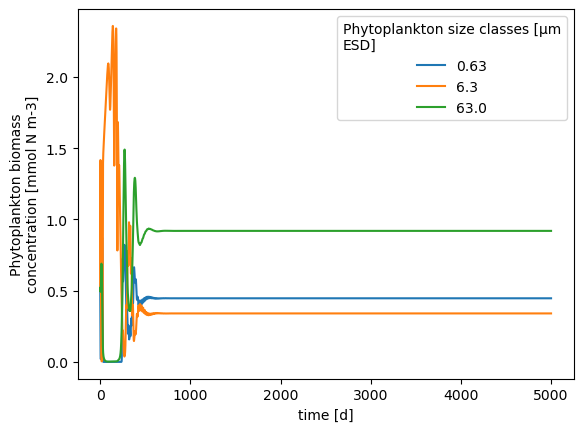

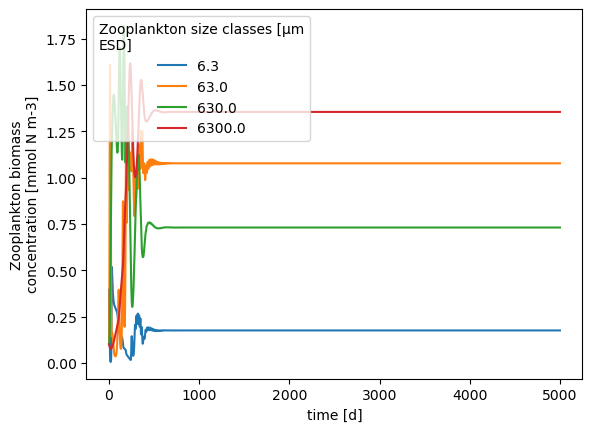

In [5]:
import matplotlib.pyplot as plt
hom = 0.026118181818181818
hom_array = np.array([0, 0, 0, hom])
outx = run_model_test({'GGE__gge':0.3705050505050505,'HigherOrderMortality__rate': hom_array})#.Phytoplankton__biomass.plot.line(x='time')
outx.Phytoplankton__biomass.plot.line(x='time')
plt.show()
outx.Zooplankton__biomass.plot.line(x='time')

In [26]:
# --- Parameters (Picklable Primitives) ---
P_num = 3
Z_num = 4
phyto_init = np.tile(.5, (P_num))
zoo_init = np.tile(.1, (Z_num))

phyto_sizes = [0.63, 6.3, 63]
zoo_sizes = [6.3, 63, 630, 6300]

phyto_ks = [0.062, 0.45, 3.3]
phyto_mu0 = [1.0, 1.26, 0.42]

phyto_mortality = [1.0, 0.02, 0.02]
phyto_mort_exponent = [2.0, 1.0, 1.0]
phyto_recycling = [1.0, 0.1, 0.1]

zoo_imax = [10.0, 3.3, 1.1, 0.36]
zoo_Ki = 3.0
zoo_frac_assim = 0.7
zoo_frac_excreted = 0.45
zoo_gge = 0.25

zoo_prey_avail = np.array([[1, 0, 0, 0, 0, 0, 0], 
                           [0, 1, 0, 1, 0, 0, 0], 
                           [0, 0, 1, 0, 1, 0, 0], 
                           [0, 0, 0, 0, 0, 1, 0]])

zoo_frac_egest_recycled = [1, 1, 0, 0]
zoo_higherordermortality = [0.02,0.02,0.02,0.02]
zoo_mort_exponent = [1, 1, 1, 2]
zoo_frac_mortylity_recycled = [0, 0, 0, 0.5]

nutrient_input = 0.13

# 💡 BASE_INPUT_VARS: Complete set of fixed inputs.
NEW_INPUT_VARS = {
    # State variables
    'Nutrient':{'value_label':'N','value_init':1.0},
    'Phytoplankton':{'biomass_label':'P','biomass_init':phyto_init, 'phyto_index':phyto_sizes},
    'Zooplankton':{'biomass_label':'Z','biomass_init':zoo_init, 'zoo_index': zoo_sizes},
    # Flows:
    'Inflow':{'forcing':'N0', 'rate':1., 'var':'N'},
    # Growth
    'Growth':{'resource':'N', 'consumer':'P', 'halfsat':phyto_ks, 'mu_max':phyto_mu0},
    # Grazing and GGE
    'Grazing':{'resource':'P', 'consumer':'Z', 'Imax':zoo_imax, 'KsZ':zoo_Ki, 'phiPZ':zoo_prey_avail},
    'GGE':{'grazed_phyto':'P', 'grazed_zoo':'Z', 'assimilated_consumer':'Z', 'egested_detritus':'N', 
            'R':zoo_frac_excreted, 'alpha':zoo_frac_assim, 'f_I':zoo_frac_egest_recycled, 'gge':zoo_gge},
    # Mortality
    'PhytoMortality':{'population':'P', 'nutrient':'N', 'rate':phyto_mortality, 'exponent':phyto_mort_exponent, 'recycling':phyto_recycling},
    'HigherOrderMortality':{'population':'Z', 'nutrient':'N', 'rate':zoo_higherordermortality, 'exponent':zoo_mort_exponent, 'recycling':zoo_frac_mortylity_recycled},
    # Forcings
    'N0':{'forcing_label':'N0', 'value':nutrient_input},
}

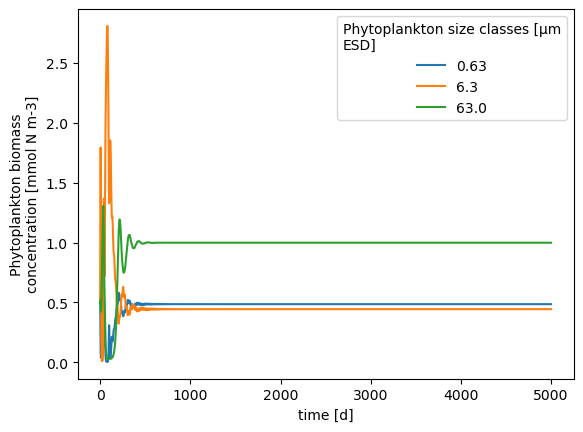

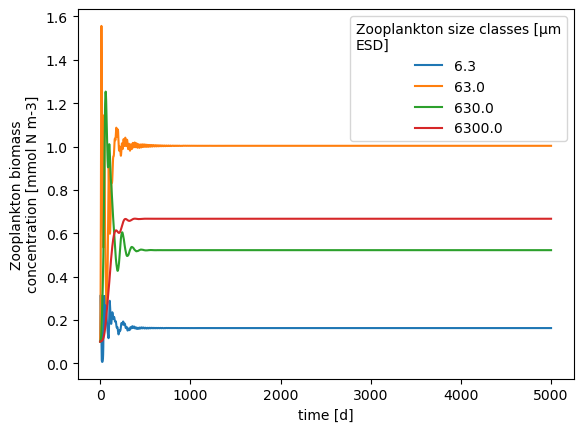

In [27]:
outx = run_model_test(NEW_INPUT_VARS)#.Phytoplankton__biomass.plot.line(x='time')
outx.Phytoplankton__biomass.plot.line(x='time')
plt.show()
outx.Zooplankton__biomass.plot.line(x='time')